In [1]:
import pytorch3d.structures
import pytorch3d.renderer
import pytorch3d.io
import numpy as np
import torch
import imageio
import mcubes
import matplotlib.pyplot as plt

In [2]:
voxel_size=64
min_value = -2.0
max_value = 2.0
x = torch.Tensor(np.linspace(min_value, max_value, voxel_size))
y = torch.Tensor(np.linspace(min_value, max_value, voxel_size))
z = torch.Tensor(np.linspace(min_value, max_value, voxel_size))
grid_x, grid_y, grid_z = torch.meshgrid(x, y, z)

/home/huyn/miniconda3/envs/learning3d/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
# Represent a sphere in implicit func
voxels =  grid_x ** 2 + grid_y ** 2 + grid_z ** 2 - 1 # x^2 + y^2 + z^2 - 1
vertices, faces = mcubes.marching_cubes(voxels.numpy(), 0) # extract 0-level set (x^2 + y^2 + z^2 - 1 = 0)

In [4]:
vertices.shape, faces.shape

((4728, 3), (9452, 3))

In [5]:
vertices = torch.Tensor(vertices).float()
faces = torch.Tensor(faces.astype(int))

In [6]:
vertices, faces

(tensor([[15.9590, 29.0000, 31.0000],
         [16.0000, 28.7812, 31.0000],
         [16.0000, 29.0000, 30.3438],
         ...,
         [47.1035, 33.0000, 33.0000],
         [47.0410, 34.0000, 31.0000],
         [47.0410, 34.0000, 32.0000]]),
 tensor([[2.0000e+00, 0.0000e+00, 1.0000e+00],
         [1.0000e+00, 3.0000e+00, 4.0000e+00],
         [0.0000e+00, 3.0000e+00, 1.0000e+00],
         ...,
         [4.7270e+03, 4.6830e+03, 4.7260e+03],
         [4.6850e+03, 4.6830e+03, 4.7270e+03],
         [4.7270e+03, 4.6730e+03, 4.6850e+03]]))

In [7]:
# Vertex coordinates are indexed by array position, so we need to
# renormalize the coordinate system.
vertices = (vertices / voxel_size) * (max_value - min_value) + min_value

In [8]:
textures = (vertices - vertices.min()) / (vertices.max() - vertices.min())
textures = pytorch3d.renderer.TexturesVertex(textures.unsqueeze(0))

mesh = pytorch3d.structures.Meshes(vertices.unsqueeze(0), faces.unsqueeze(0), textures=textures)
lights = pytorch3d.renderer.DirectionalLights()
R, T = pytorch3d.renderer.look_at_view_transform(dist=2, elev=0, azim=30)
cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)

rasterizer = pytorch3d.renderer.MeshRasterizer(cameras=cameras)
shader = pytorch3d.renderer.HardPhongShader(cameras=cameras, lights=lights)
renderer = pytorch3d.renderer.MeshRenderer(rasterizer, shader)

rend = renderer(mesh, cameras=cameras, lights=lights)

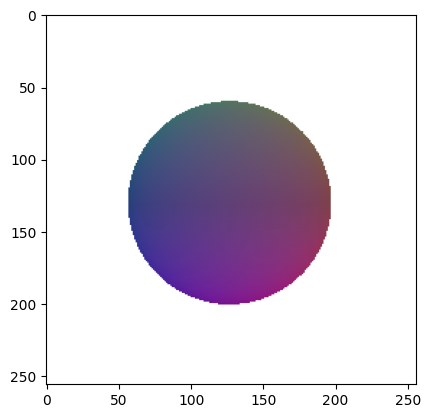

In [9]:
plt.plot(figsize=(10,10))
plt.imshow(rend[0, ..., :3])

In [34]:
# Represent a torus
import math
R = 2.5
r = 0.7

max_value = -R-r
min_value = R+r


x = torch.Tensor(np.linspace(min_value, max_value, voxel_size))
y = torch.Tensor(np.linspace(min_value, max_value, voxel_size))
z = torch.Tensor(np.linspace(min_value, max_value, voxel_size))
grid_x, grid_y, grid_z = torch.meshgrid(x, y, z)
voxels = (torch.sqrt(grid_x**2 + grid_y**2) - R )**2 + grid_z**2 - r**2

In [35]:
voxels.shape, voxels

(torch.Size([64, 64, 64]),
 tensor([[[13.8526, 13.2127, 12.5935,  ..., 12.5935, 13.2127, 13.8526],
          [13.5690, 12.9292, 12.3100,  ..., 12.3100, 12.9292, 13.5690],
          [13.3001, 12.6603, 12.0411,  ..., 12.0411, 12.6603, 13.3001],
          ...,
          [13.3001, 12.6603, 12.0411,  ..., 12.0411, 12.6603, 13.3001],
          [13.5690, 12.9292, 12.3100,  ..., 12.3100, 12.9292, 13.5690],
          [13.8526, 13.2127, 12.5935,  ..., 12.5935, 13.2127, 13.8526]],
 
         [[13.5690, 12.9292, 12.3100,  ..., 12.3100, 12.9292, 13.5690],
          [13.2912, 12.6514, 12.0322,  ..., 12.0322, 12.6514, 13.2912],
          [13.0282, 12.3884, 11.7692,  ..., 11.7692, 12.3884, 13.0282],
          ...,
          [13.0282, 12.3884, 11.7692,  ..., 11.7692, 12.3884, 13.0282],
          [13.2912, 12.6514, 12.0322,  ..., 12.0322, 12.6514, 13.2912],
          [13.5690, 12.9292, 12.3100,  ..., 12.3100, 12.9292, 13.5690]],
 
         [[13.3001, 12.6603, 12.0411,  ..., 12.0411, 12.6603, 13.3001],
 

In [36]:
# Normalize coords

vertices, faces = mcubes.marching_cubes(voxels.numpy(), 0)
vertices = (vertices / voxel_size) * (max_value - min_value) + min_value

In [37]:
print(vertices)
vertices.min(), vertices.max()

[[ 3.10707043  0.8         0.1       ]
 [ 3.1         0.82849392  0.1       ]
 [ 3.1         0.8         0.15006483]
 ...
 [-3.01441002 -0.6        -0.1       ]
 [-3.00707043 -0.7         0.1       ]
 [-3.00707043 -0.7         0.        ]]


(-3.097617118930871, 3.197617118930871)

In [38]:
textures = torch.Tensor((vertices - vertices.min()) /  (vertices.max() - vertices.min()))
textures = pytorch3d.renderer.TexturesVertex(textures.unsqueeze(0))

mesh_torus = pytorch3d.structures.Meshes(torch.Tensor(vertices).unsqueeze(0), torch.Tensor(faces.astype(int)).unsqueeze(0), textures=textures)

In [39]:
mesh_torus

In [40]:
lights = pytorch3d.renderer.DirectionalLights()
R, T = pytorch3d.renderer.look_at_view_transform(dist=6, elev=0, azim=0)
cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)

rasterizer = pytorch3d.renderer.MeshRasterizer(cameras=cameras)
shader = pytorch3d.renderer.HardPhongShader(cameras=cameras, lights=lights)
renderer = pytorch3d.renderer.MeshRenderer(rasterizer, shader)

rend = renderer(mesh_torus, cameras=cameras, lights=lights)

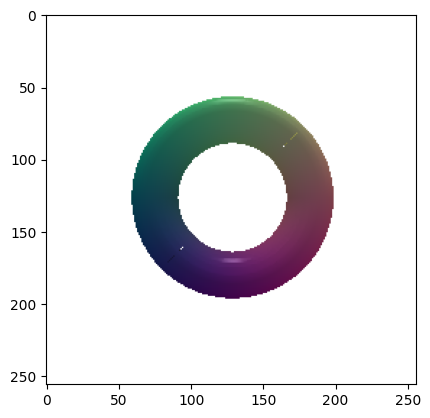

In [41]:
plt.plot(figsize=(10, 10))
plt.imshow(rend[0, ..., :3])

## Render spinning torus GIF

In [42]:
frames = []

for azim in range(0, 360, 10):
    lights = pytorch3d.renderer.DirectionalLights()
    R, T = pytorch3d.renderer.look_at_view_transform(dist=6, elev=0, azim=azim)
    cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)
    
    rasterizer = pytorch3d.renderer.MeshRasterizer(cameras=cameras)
    shader = pytorch3d.renderer.HardPhongShader(cameras=cameras, lights=lights)
    renderer = pytorch3d.renderer.MeshRenderer(rasterizer, shader)
    
    rend = renderer(mesh_torus, cameras=cameras, lights=lights)
    frames.append(   rend[0, ..., :3] )

In [43]:
imageio.mimsave("torus_implicit.gif", [(f.numpy() * 255).astype(np.uint8) for f in frames], duration=1000/10, loop=0)

In [114]:
frames[0].numpy().shape

(256, 256, 3)

# Render hyperboloid

In [229]:
a, b, c = 2.0, 1.0, 3.0
min_val = -5.0
max_val = 5.0
voxel_size = 100
samples = torch.Tensor(np.linspace(min_val, max_val, voxel_size))
X, Y, Z = torch.meshgrid(samples, samples, samples)

voxels = X**2 / a**2 + Y**2 / b**2 - Z**2 / c**2 - 1
voxels

tensor([[[27.4722, 27.5833, 27.6922,  ..., 27.6922, 27.5833, 27.4722],
         [26.4723, 26.5834, 26.6923,  ..., 26.6923, 26.5834, 26.4723],
         [25.4928, 25.6039, 25.7128,  ..., 25.7128, 25.6039, 25.4928],
         ...,
         [25.4928, 25.6039, 25.7128,  ..., 25.7128, 25.6039, 25.4928],
         [26.4723, 26.5834, 26.6923,  ..., 26.6923, 26.5834, 26.4723],
         [27.4722, 27.5833, 27.6922,  ..., 27.6922, 27.5833, 27.4722]],

        [[27.2222, 27.3333, 27.4422,  ..., 27.4422, 27.3333, 27.2222],
         [26.2223, 26.3334, 26.4423,  ..., 26.4423, 26.3334, 26.2223],
         [25.2429, 25.3540, 25.4628,  ..., 25.4628, 25.3540, 25.2429],
         ...,
         [25.2429, 25.3540, 25.4628,  ..., 25.4628, 25.3540, 25.2429],
         [26.2223, 26.3334, 26.4423,  ..., 26.4423, 26.3334, 26.2223],
         [27.2222, 27.3333, 27.4422,  ..., 27.4422, 27.3333, 27.2222]],

        [[26.9774, 27.0885, 27.1973,  ..., 27.1973, 27.0885, 26.9774],
         [25.9775, 26.0886, 26.1974,  ..., 26

In [261]:
vertices, faces = mcubes.marching_cubes(voxels.numpy(), 0)
# renormalize the coord system

vertices = (vertices / voxel_size) * (max_val - min_val) + min_val
textures = torch.Tensor((vertices - vertices.min()) / (vertices.max() - vertices.min()))
textures = pytorch3d.renderer.TexturesVertex(torch.Tensor(textures).unsqueeze(0))

In [262]:
vertices.shape, textures.verts_features_packed().shape

((19536, 3), torch.Size([19536, 3]))

In [263]:
mesh = pytorch3d.structures.Meshes(torch.Tensor(vertices).unsqueeze(0).float(), torch.Tensor(faces.astype(int)).unsqueeze(0), textures)

In [264]:
R, T = pytorch3d.renderer.look_at_view_transform(dist=9.0, elev=90.0, azim=0.0)
cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)
lights = pytorch3d.renderer.PointLights(location=((0, 5, 0),))
rend = renderer(mesh, cameras=cameras, lights=lights)

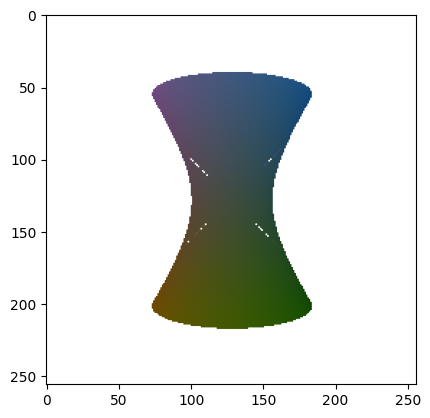

In [265]:
plt.plot(figsize=(10, 10))
plt.imshow(rend.squeeze(0))

In [266]:
frames = []

for azim in range(0, 360, 10):
    R, T = pytorch3d.renderer.look_at_view_transform(dist=9.0, elev=90.0, azim=azim)
    cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)
    lights = pytorch3d.renderer.PointLights(location=((0, 5, 0),))
    rend = renderer(mesh, cameras=cameras, lights=lights)
    frames.append(   rend[0, ..., :3] )

In [267]:
imageio.mimsave("hyperboloid_implicit.gif", [(f.numpy() * 255).astype(np.uint8) for f in frames], duration=1000/10, loop=0)